# Fase 2: Preprocesamiento y Data Augmentation
## Sistema Inteligente para la Detección de Tumores Cerebrales en MRI mediante CNN

**Tareas**:
1. Resize uniforme (224×224)
2. Normalización de píxeles [0,1]
3. Split train/validation/test
4. Data Augmentation (rotación, flip, zoom, brillo, contraste)

In [19]:
import sys
import os

print("[1/6] Importando numpy...")
import numpy as np
print("[2/6] Importando matplotlib...")
import matplotlib.pyplot as plt
print("[3/6] Importando tensorflow (esto puede tomar varios minutos)...")
import tensorflow as tf

sys.path.append(os.path.abspath(".."))

print("[4/6] Cargando configuración...")
from src.utils.config import (
    TRAINING_DIR, TESTING_DIR, CLASSES, CLASS_MAP,
    IMG_SIZE, BATCH_SIZE, SEED, VALIDATION_SPLIT, TEST_SPLIT
)
print("[5/6] Cargando módulos de datos (puede tardar por opencv)...")
from src.data.loader import load_image_paths, load_and_preprocess_image
from src.data.preprocessing import encode_labels, split_dataset
from src.data.augmentation import get_tf_generators, create_data_augmentation
print("[6/6] ¡Importaciones completadas!")

%matplotlib inline

[1/6] Importando numpy...
[2/6] Importando matplotlib...
[3/6] Importando tensorflow (esto puede tomar varios minutos)...
[4/6] Cargando configuración...
[5/6] Cargando módulos de datos (puede tardar por opencv)...
[6/6] ¡Importaciones completadas!


### 1. Carga de imágenes con redimensionamiento y normalización

In [20]:
print("Cargando imágenes de Training...")
train_paths, train_labels = load_image_paths(TRAINING_DIR)

X_train_raw = []
y_train_raw = []
for path, label in zip(train_paths, train_labels):
    img = load_and_preprocess_image(path, IMG_SIZE)
    if img is not None:
        X_train_raw.append(img)
        y_train_raw.append(label)

X_train_raw = np.array(X_train_raw)
y_train_raw = np.array(y_train_raw)
print(f"Training: {X_train_raw.shape}, labels: {y_train_raw.shape}")

print("\nCargando imágenes de Testing...")
test_paths, test_labels = load_image_paths(TESTING_DIR)

X_test_raw = []
y_test_raw = []
for path, label in zip(test_paths, test_labels):
    img = load_and_preprocess_image(path, IMG_SIZE)
    if img is not None:
        X_test_raw.append(img)
        y_test_raw.append(label)

X_test_raw = np.array(X_test_raw)
y_test_raw = np.array(y_test_raw)
print(f"Testing: {X_test_raw.shape}, labels: {y_test_raw.shape}")

Cargando imágenes de Training...
Training: (5600, 224, 224, 3), labels: (5600,)

Cargando imágenes de Testing...
Testing: (1600, 224, 224, 3), labels: (1600,)


### 2. Split Train / Validation / Test

Del conjunto de Training tomamos:
- 70% para entrenamiento
- 15% para validación
- 15% para test (adicional al Testing oficial)

El Testing oficial se usará como conjunto de evaluación final (hold-out).

In [21]:
y_train_enc = encode_labels(y_train_raw)
y_test_enc = encode_labels(y_test_raw)

X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(
    X_train_raw, y_train_enc,
    val_split=VALIDATION_SPLIT,
    test_split=TEST_SPLIT
)

print("DISTRIBUCIÓN DE LOS DATOS")
print("=" * 40)
print(f"Train:      {X_train.shape[0]:>5} imágenes ({X_train.shape[0]/len(X_train_raw)*100:.1f}%)")
print(f"Validation: {X_val.shape[0]:>5} imágenes ({X_val.shape[0]/len(X_train_raw)*100:.1f}%)")
print(f"Test(hold): {X_test.shape[0]:>5} imágenes ({X_test.shape[0]/len(X_train_raw)*100:.1f}%)")
print(f"Testing(of):{X_test_raw.shape[0]:>5} imágenes (oficial, hold-out)")
print(f"Total:      {len(X_train_raw) + len(X_test_raw):>5} imágenes")

DISTRIBUCIÓN DE LOS DATOS
Train:       3920 imágenes (70.0%)
Validation:   840 imágenes (15.0%)
Test(hold):   840 imágenes (15.0%)
Testing(of): 1600 imágenes (oficial, hold-out)
Total:       7200 imágenes


### 3. Data Augmentation

Aplicamos las siguientes transformaciones aleatorias:
- Flip horizontal
- Rotación (±10°)
- Zoom (±10%)
- Brillo (±10%)
- Contraste (±10%)

In [22]:
augmentation = create_data_augmentation()

print("CAPA DE DATA AUGMENTATION")
augmentation.summary()

CAPA DE DATA AUGMENTATION


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_7 (RandomFlip)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_7               │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_7 (RandomZoom)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_7             │ ?                      │   0 (unbuilt) │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_7               │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.4193463..2.3379846].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [23.581842..24.521667].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [20.87154..21.83622].


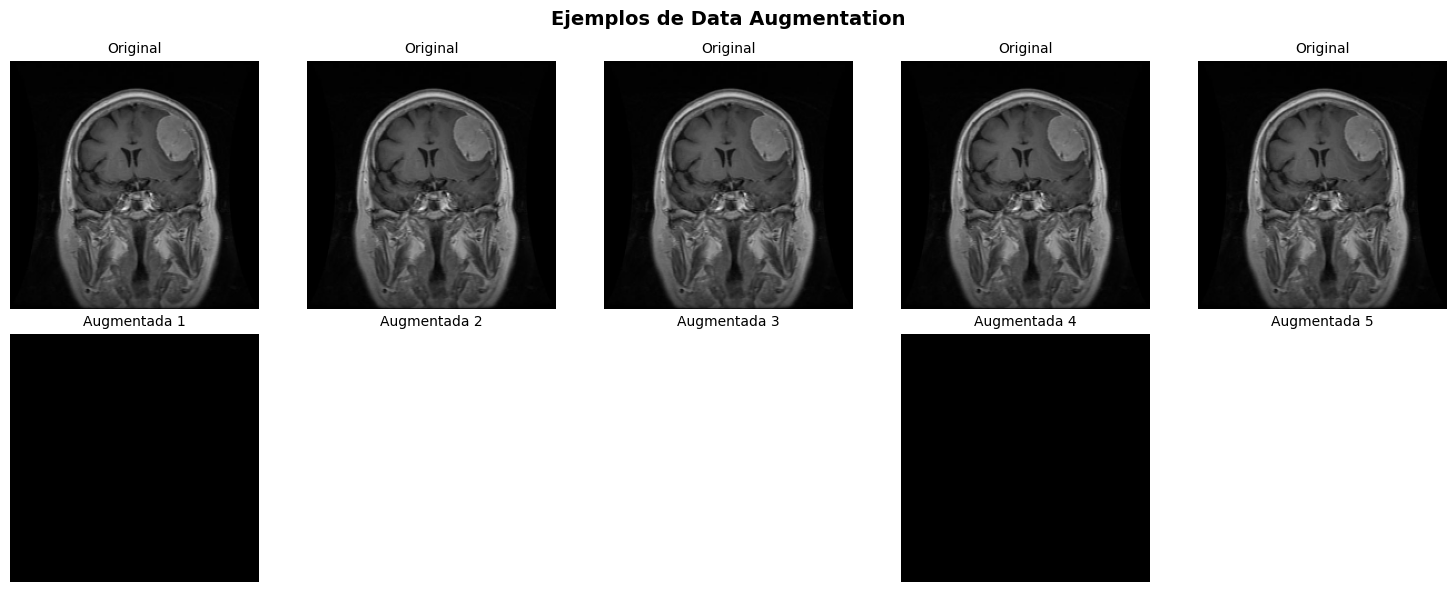

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

sample_img = X_train[0:1]

for i in range(5):
    augmented = augmentation(sample_img, training=True)
    axes[0, i].imshow(sample_img[0])
    axes[0, i].set_title('Original', fontsize=10)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(augmented[0])
    axes[1, i].set_title(f'Augmentada {i+1}', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('Ejemplos de Data Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/preprocessing_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()  

### 4. Creación de generadores TensorFlow

In [24]:
train_ds, val_ds, test_ds = get_tf_generators(
    X_train, X_val, X_test,
    y_train, y_val, y_test,
    batch_size=BATCH_SIZE
)

print("GENERADORES TENSORFLOW CREADOS")
print(f"Train batches: {len(list(train_ds.take(1)))}")
print(f"Val batches:   {len(list(val_ds.take(1)))}")
print(f"Test batches:  {len(list(test_ds.take(1)))}")

GENERADORES TENSORFLOW CREADOS
Train batches: 1
Val batches:   1
Test batches:  1


### 5. Resumen del preprocesamiento

| Parámetro | Valor |
|---|---|
| Tamaño de imagen | 224×224 píxeles |
| Canales | 3 (RGB, convertido desde escala de grises) |
| Normalización | [0, 1] (división entre 255) |
| Split Train/Val/Test | 70% / 15% / 15% |
| Data Augmentation | Flip, Rotación (±10°), Zoom (±10%), Brillo (±10%), Contraste (±10%) |
| Batch size | 32 |
| Testing oficial | Hold-out final (1600 imágenes) |

**Datos listos para entrenamiento en Fase 3 (CNN propia).**